# Лабораторна робота 3

In [1]:
import time
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, Flatten, BatchNormalization, Activation, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\BOS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import csr_matrix, issparse


## Завантаження набору даних, обробка та поділи датасету на: навчальний, валідаційний та тестовий

- ### завантаження даних

In [2]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

c:\Users\BOS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


- ### нормалізація даних

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

- ### зміна форми міток

In [4]:
print("Before")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

y_train = y_train.flatten()
y_test =y_test.flatten()

print(f"\nAfter")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Before
y_train: (50000, 1)
y_test: (10000, 1)

After
y_train: (50000,)
y_test: (10000,)


- ### поділ датасету

In [24]:
y_test_cat = to_categorical(y_test, 100)
print(f"Test - {x_test.shape}, {y_test_cat.shape}")

Test - (10000, 32, 32, 3), (10000, 100)


In [ ]:
x_train, x_val, y_train, y_val = train_test_split( x_train, y_train, test_size=0.2, random_state = 42 , stratify=y_train )

In [25]:
y_train_cat = to_categorical(y_train, 100)
print(f"Train - {x_train.shape}, {y_train_cat.shape}")

y_val_cat = to_categorical(y_val, 100)
print(f"Validation - {x_val.shape}, {y_val_cat.shape}")

Train - (40000, 32, 32, 3), (40000, 100)
Validation - (10000, 32, 32, 3), (10000, 100)


## Архітектура згорткової нейронної мережі для класифікації зображень
- ### Функція побудови моделі

In [ ]:
def build_model(filters1=64, filters2=128, activation="relu",
                 use_dropout=True, use_batchnorm=True):

    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))

    model.add(Conv2D(filters1, (3, 3), padding="same", use_bias=False))
    if use_batchnorm: model.add(BatchNormalization())
    model.add(Activation(activation))

    model.add(Conv2D(filters1, (3, 3), padding="same", use_bias=False))
    if use_batchnorm: model.add(BatchNormalization())
    model.add(Activation(activation))

    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(filters2, (3, 3), padding="same", use_bias=False))
    if use_batchnorm: model.add(BatchNormalization())
    model.add(Activation(activation))

    model.add(Conv2D(filters2, (3, 3), padding="same", use_bias=False))
    if use_batchnorm: model.add(BatchNormalization())
    model.add(Activation(activation))

    model.add(MaxPooling2D((2, 2)))

    if use_dropout: model.add(Dropout(0.3))
    model.add(Flatten())

    model.add(Dense(128, use_bias=False))
    if use_batchnorm: model.add(BatchNormalization())
    model.add(Activation(activation))

    if use_dropout: model.add(Dropout(0.5))

    model.add(Dense(100, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

- ### Функція для побудови графіка

In [8]:
def plot(history):

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Навчання')
    plt.plot(history.history['val_accuracy'], label='Валідація')
    plt.title('Точність моделі')
    plt.xlabel('Епоха')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Навчання')
    plt.plot(history.history['val_loss'], label='Валідація')
    plt.title('Втрати (Loss)')
    plt.xlabel('Епоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()

## Baseline

In [9]:
results = {}

In [10]:
baseline_model = build_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,252 (5.04 MB)

 Trainable params: 1,321,252 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
        monitor="val_loss",
        patience = 3,
        restore_best_weights=True
    )
    
start_time = time.time()
    
hist = baseline_model.fit( x_train, y_train_cat, validation_data=(x_val, y_val_cat), epochs = 15, batch_size=128, callbacks=[early_stop], verbose=1)

training_time  = time.time() - start_time

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 162s 508ms/step - accuracy: 0.0831 - loss: 4.0623 - val_accuracy: 0.1531 - val_loss: 3.6273
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 513ms/step - accuracy: 0.2268 - loss: 3.2151 - val_accuracy: 0.2371 - val_loss: 3.1977
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 504ms/step - accuracy: 0.3293 - loss: 2.7020 - val_accuracy: 0.3136 - val_loss: 2.8152
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 502ms/step - accuracy: 0.4067 - loss: 2.3156 - val_accuracy: 0.3441 - val_loss: 2.6897
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 508ms/step - accuracy: 0.4721 - loss: 2.0059 - val_accuracy: 0.3525 - val_loss: 2.7791
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 505ms/step - accuracy: 0.5320 - loss: 1.7535 - val_accuracy: 0.3244 - val_loss: 3.1437
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 506ms/step - accuracy: 0.5775 - loss: 1.5503 - val_accuracy: 0.3276 - val_loss: 3.2264


In [26]:
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test_cat, verbose=0)

results["Baseline"] = {
        "accuracy": test_accuracy,
        "time": training_time,
        "history": hist.history
    }

print(f"\nТочність на тестових даних (Baseline): {test_accuracy*100:.2f}%")
print("Training time:", round(training_time , 2), "sec")


Точність на тестових даних (Baseline): 35.28%
Training time: 2169.47 sec


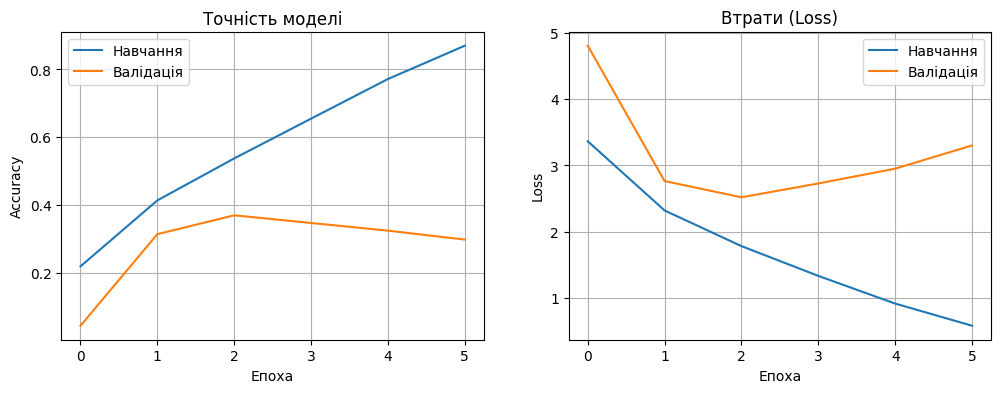

In [27]:
plot(hist)

## Eксперименти

In [14]:
configs = {
    "More Filters": {"filters1": 128, "filters2": 256, "activation": "relu", "use_dropout": False, "use_batchnorm": False },
    "Elu Activation": {"filters1": 64, "filters2": 128, "activation": "elu", "use_dropout": False, "use_batchnorm": False},
    "Tanh Activation": {"filters1": 64, "filters2": 128, "activation": "tanh", "use_dropout": False, "use_batchnorm": False},
    "With Dropout": {"filters1": 64, "filters2": 128, "activation": "relu", "use_dropout": True, "use_batchnorm": False},
    "With BatchNorm": {"filters1": 64, "filters2": 128, "activation": "relu", "use_dropout": False, "use_batchnorm": True}
}


Експеримент: More Filters


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 128)    │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,145,700 (12.00 MB)

 Trainable params: 3,145,700 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

Точність на тестових даних (More Filters): 32.89%
Training time: 3736.01 sec


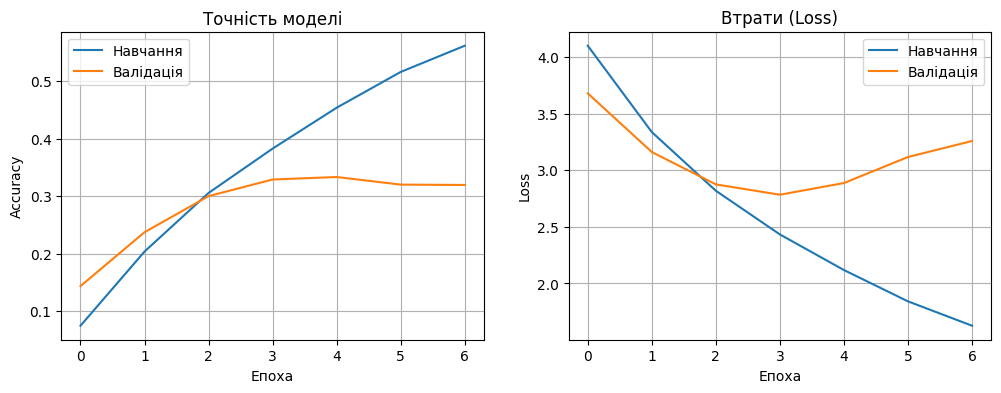


Експеримент: Elu Activation


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,252 (5.04 MB)

 Trainable params: 1,321,252 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Точність на тестових даних (Elu Activation): 34.55%
Training time: 784.26 sec


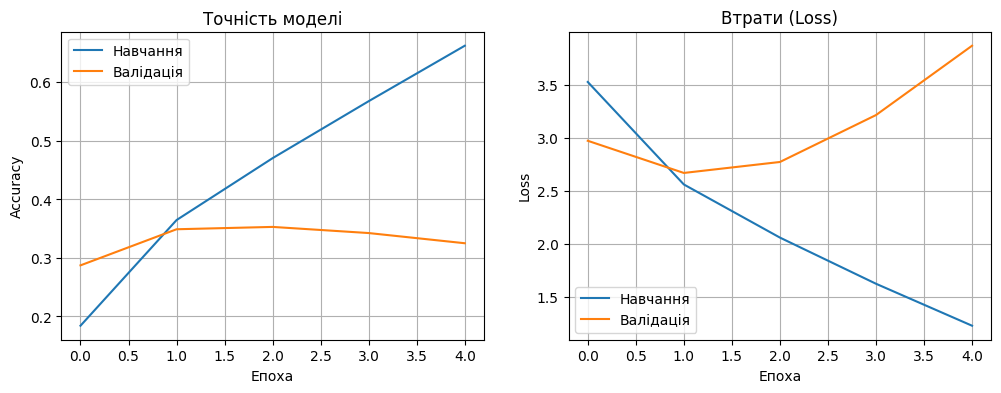


Експеримент: Tanh Activation


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,252 (5.04 MB)

 Trainable params: 1,321,252 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Точність на тестових даних (Tanh Activation): 34.51%
Training time: 1538.04 sec


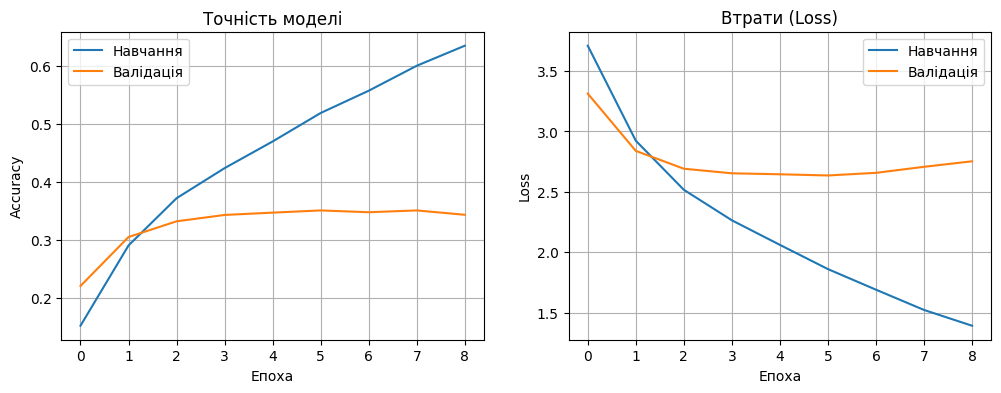


Експеримент: With Dropout


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,252 (5.04 MB)

 Trainable params: 1,321,252 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Точність на тестових даних (With Dropout): 39.30%
Training time: 2513.49 sec


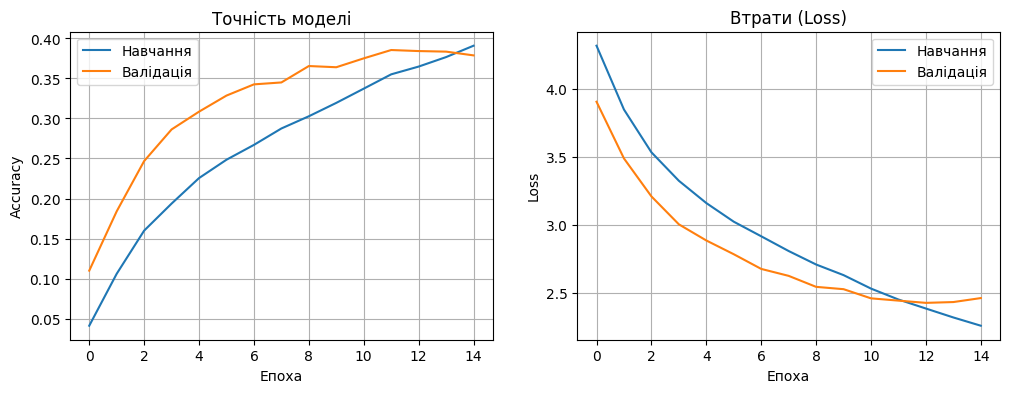


Експеримент: With BatchNorm


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_55 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_56 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_59 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,300 (5.05 MB)

 Trainable params: 1,322,276 (5.04 MB)

 Non-trainable params: 1,024 (4.00 KB)

Точність на тестових даних (With BatchNorm): 37.26%
Training time: 2169.47 sec


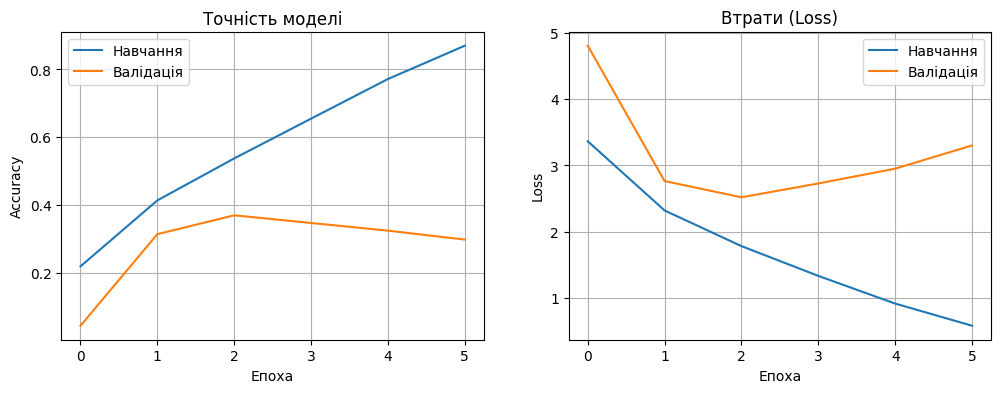

In [20]:
for name, config in configs.items():
    
    print(f"\nЕксперимент: {name}")

    model = build_model(**config) 
    
    model.summary()
    
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience = 3,
        restore_best_weights=True
    )

    start_time = time.time()

    hist = model.fit(
        x_train, y_train_cat,
        validation_data=(x_val, y_val_cat),
        epochs = 15,
        batch_size=128,
        callbacks=[early_stop],
        verbose=0
    )
    
    training_time  = time.time() - start_time

    test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
    
    results[name] = {
        "accuracy": test_accuracy,
        "time": training_time,
        "history": hist.history
    }
    
    print(f"Точність на тестових даних ({name}): {test_accuracy*100:.2f}%")
    print("Training time:", round(training_time , 2), "sec")
    
    plot(hist)

## Порівняння результатів

In [28]:
df = pd.DataFrame.from_dict(results, orient="index")
df = df[["accuracy", "time"]]

print(df)

                 accuracy         time
Baseline           0.3528  2169.474748
More Filters       0.3289  3736.008785
Elu Activation     0.3455   784.257029
Tanh Activation    0.3451  1538.042082
With Dropout       0.3930  2513.486876
With BatchNorm     0.3726  2169.474748


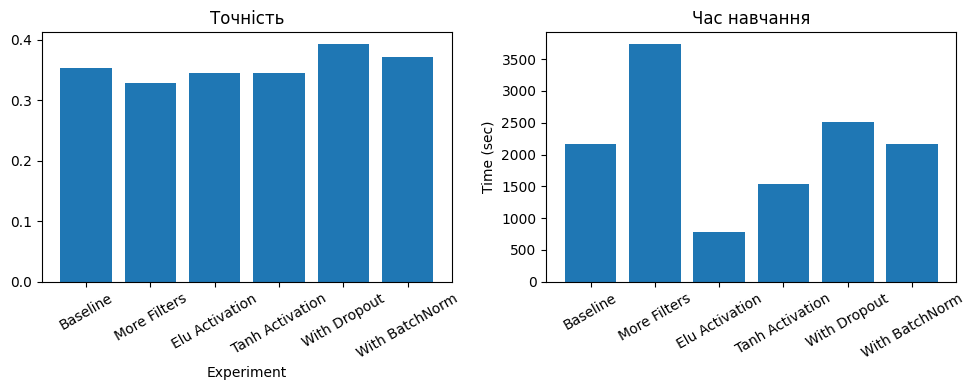

In [29]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(df.index, df["accuracy"])
plt.xticks(rotation=30)
plt.title("Точність")
plt.xlabel("Experiment")

plt.subplot(1, 2, 2)
plt.bar(df.index, df["time"])
plt.xticks(rotation=30)
plt.title("Час навчання")
plt.ylabel("Time (sec)")

plt.tight_layout()

In [30]:
best_name = max(results, key=lambda x: results[x]["accuracy"])
best_acc = results[best_name]["accuracy"]
best_time = results[best_name]["time"]

print("\n------ Найкраща модель -------")
print(f"Модель: {best_name}")
print(f"Accuracy: {best_acc:.4f}")
print(f"Training time: {best_time:.2f} sec")


------ Найкраща модель -------
Модель: With Dropout
Accuracy: 0.3930
Training time: 2513.49 sec
